- The last layer(s) of the network should be a classifier for sentiment polarity, and should be designed by you. There is no requirement on the technical complexity of this classifier. This implies that you can't just load a ready-made pipeline.
- Use pyTorch's Dataset and DataLoader classes for loading the data.
- Train the network using batches of at least 2.
- Compare performance between some model and a similar distilled one (e.g. BERT and DistilBERT).


# Sentimentanalys för antik grekiska (assignment 3, Machine Learning for NLP)

# Plan och förberedelse

In [2]:
import torch
print(torch.__version__)
print(torch.__file__)

if torch.xpu.is_available():
    device = torch.device("xpu:0")
    available, total = torch.xpu.mem_get_info(device)
    print(f"{total / 1024 ** 3:.1f} GB, {100 * available / total:.1f}% tillgängligt.")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
    max_memory = torch.xpu.max_memory_allocated
else:
    device = torch.device("cpu")

2.8.0+xpu
/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/torch/__init__.py
11.3 GB, 100.0% tillgängligt.


KaLM 2.5 är en lite kinkig modell som varken gillar senaste transformers eller för gamla versioner. En fungerande setup är `transformers 4.57.6` och `sentence-transformers 5.0.0`

In [2]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

import sentence_transformers
print(sentence_transformers.__version__)
print(transformers.__file__)

/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.37.0
/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/transformers/__init__.py
5.3.0
/home/urdatorn/.pyenv/versions/xpu/lib/python3.13/site-packages/transformers/__init__.py


# Embeddings

Först laddar vi och förbereder datan som ska embeddas. Jag har två filer: en med 300 meningar från Emelie. Dessa är från romerska/bysantinska romaner. Den andra är 30 meningar från Aristofanes som jag själv klassificerat.

In [6]:
with open("sentiment_aristophanes.tsv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    sentences_albin = [line.split("\t")[0] for line in lines[1:]]
    labels_albin = [line.split("\t")[1].replace("\n", "") for line in lines[1:]]

# vi förbereder också Emelies:
with open("sentiment_romaner.tsv", "r", encoding="utf-8") as f:
    lines = f.readlines()
    sentences_emelie = [line.split("\t")[0] for line in lines[1:]]
    labels_emelie = [line.split("\t")[1].replace("\n", "") for line in lines[1:]]

random_start = torch.randint(low=1, high=len(sentences_albin) + 1 - 10, size=(1,)).item()
end = random_start + 3

print("Vi checkar några exempel, t.ex. 3 meningar från och med mening nummer",random_start, ":\n")
for sentence, label in zip(sentences_albin[random_start: end], labels_albin[random_start: end]):
    print(sentence[:30], ": ", label)

# Manualen för F.cross_entropy säger att "each value should be between [0,C)". Med C = 3, får vi [0, 1, 2]
label_map = {
    "NEG": 0,
    "NEU": 1,
    "POS": 2
}

print(labels_albin[:10])

labels_albin = [label_map[l] for l in labels_albin]
labels_emelie = [label_map[l] for l in labels_emelie]

print(labels_albin[:10])

Vi checkar några exempel, t.ex. 3 meningar från och med mening nummer 16 :

Ὦνδρες πρυτάνεις, ἀδικεῖτε τὴν :  NEG
ἀδικεῖτε τὴν ἐκκλησίαν :  NEG
Ὦ Κραναὰ πόλις, ἆρ' αἰσθάνει τ :  NEG
['POS', 'POS', 'POS', 'NEG', 'POS', 'POS', 'POS', 'POS', 'POS', 'POS']
[2, 2, 2, 0, 2, 2, 2, 2, 2, 2]


In [ ]:
from sentence_transformers import SentenceTransformer
import torch

model = SentenceTransformer(
    "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5",
    trust_remote_code=True,
    model_kwargs={
        "dtype": torch.float,
        "attn_implementation": "eager",                                                               # kan ej få "pip install flash_attn" att gå igenom på klustret, ens i en container och fem timmars försök
    },
)
model.max_seq_length = 512

embeddings = model.encode(                                                                          # embeddings.shape == (num_sentences, 896)
    sentences,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
    convert_to_tensor=True,                                                                         # default är numpy array, vilket ger vårt hemmabyggda torch lager nedan hicka, så vi ber snällt om tensorer...
)

test_embeddings = model.encode(
    test_sentences,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
    convert_to_tensor=True,
)

# jag sparar vektorerna, eftersom för att generera dem krävs det en CUDA-gpu från klustret,
# men när de väl är nere så finns det inget som spottar mig från att arbeta vidare lokalt
torch.save(embeddings, "sentiment_embeddings.pt") 

print("För skojs skull inspekterar vi samma exempelmeningar:")
print(embeddings[random_start: end])

Wrote 34 records to sentiment_aristophanes.jsonl and sentiment_aristophanes.tsv
Vi checkar några exempel, t.ex. 3 meningar från och med mening nummer 15 :

στυγῶν μὲν ἄστυ :  NEG

Ὦνδρες πρυτάνεις, ἀδικεῖτε τὴν :  NEG

ἀδικεῖτε τὴν ἐκκλησίαν :  NEG



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

För skojs skull inspekterar vi samma exempelmeningar:
tensor([[-0.0454,  0.0498,  0.0221,  ...,  0.0010,  0.0045,  0.0115],
        [-0.0382,  0.0339,  0.0535,  ..., -0.0204,  0.0147,  0.0047],
        [-0.0515,  0.0471,  0.0583,  ..., -0.0340,  0.0020,  0.0216]],
       device='cuda:0')


# Dataset

In [29]:
from torch.utils.data import Dataset, DataLoader

class SetimentEmbeddingsDataset(Dataset):
    """
    Dataset consisting of 896-dimensional KaLM 2.5 embeddings of Ancient Greek sentences,
    and labels marking sentences as 0, 1, 2 for negative, neutral and positive sentiment respectively.
    
    Embeddings dtype: torch.float32 = torch.float
    Labels dtype: torch.int64 = torch.long
    """

    def __init__(self, embeddings: torch.Tensor, labels: torch.Tensor, transform=None):
        self.X = embeddings
        self.y = labels
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        x = self.X[idx]
        y = self.y[idx]

        if self.transform:
            x = self.transform(x)

        return x, y

In [ ]:
import os
import multiprocessing as mp
from functools import partial
mp.set_start_method("fork", force=True)                                # från äldre python för linux fork subprocesser

cores = os.cpu_count()
batch_size = 256

dataset = SetimentEmbeddingsDataset(embeddings, torch.tensor(labels_albin))
cats = DataLoader(dataset,                                           # https://platform.theverge.com/wp-content/uploads/sites/2/chorus/uploads/chorus_asset/file/23666725/SEGA_Genesis___June_2022_Game_Updates___Nintendo_Switch_Online_0_29_screenshot.png?quality=90&strip=all&crop=0,1.6437308868502,100,96.7125382263
                    batch_size=batch_size,                             
                    shuffle=False, 
                    num_workers=cores,                                 # All your CPU cores are belong to us. HA HA HA HA...
                    persistent_workers=False,
                    collate_fn=partial(pad_and_encode,                 # bind token2idx och tag2idx till pad_and_encode
                                       token2idx=token2idx,
                                       tag2idx=tag2idx,
                                       use_bpe=use_bpe)
  )
  return cats

# Linjärt lager

Vi designar vårt eget lager. Målet är att mappa från en batch av n 896-dimensionella vektorer till n tripletter av logits som symboliserar sentiment.

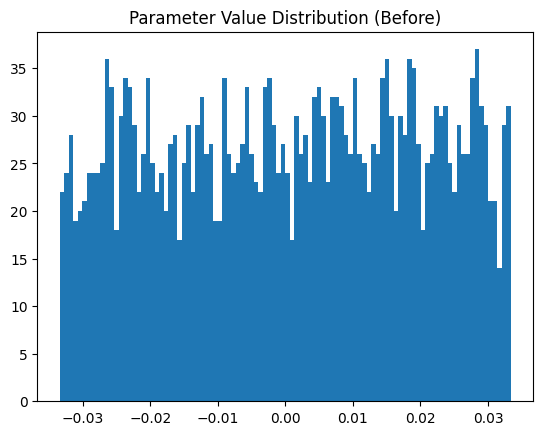

In [8]:
import matplotlib.pyplot as plt
import torch.nn as nn

class SentimentDecisionBoundariesLayer(nn.Module):                              # assuming good euclidean manifolds from the embedding model
    def __init__(self, embedding_dim):                                          # the dimensionality of the embedding
        super().__init__()
        self.linear = nn.Linear(in_features=embedding_dim, 
                                out_features=3,                                 # how many sentiment labels to get logits for! NEG, POS, NEU = 3
                                bias=True,
                                device=device,
                                dtype=torch.float)      
    
    def forward(self, sentences):
        return self.linear.forward(sentences)

model = SentimentDecisionBoundariesLayer(embedding_dim=896)                     # the nr of dims of KaLM-Embedding-V2.5
model = model.to(device)                                                        # inför träningen flyttar vi modellen till GPUn

params_before = torch.cat([p.detach().view(-1).cpu() for p in model.parameters()])
plt.hist(params_before.numpy(), bins=100)
plt.title("Parameter Value Distribution (Before)")
plt.show()

Vikterna initialiserade slumpmässigt och ger som det är logits (0.33, 0.33, 0.33) för alla input. Modellen måste alltså tränas. Först förbereder vi en train / val / test split.

In [10]:
emelie = torch.load("sentiment_embeddings_test.pt", map_location=torch.device(device))
albin = torch.load("sentiment_embeddings.pt", map_location=torch.device(device))

emelie = emelie.float()
albin = albin.float()

print(emelie.shape)
print(albin.shape)

test_size = int(emelie.shape[0] // (10/9))
train_size = int(emelie.shape[0] - test_size)

print(test_size, train_size)

# Train / val / test
embeddings_test, embeddings_train = torch.split(emelie, [test_size, train_size])          # torch.split tar en lista av custom längder. (om man ger en enda int delar den i lika delar så gott det går)
test_labels = torch.tensor(labels_emelie[:test_size], dtype=torch.int64, device=device)   # i manualen för F.cross_entropy är target i torch.int6 (= torch.long), så vi kör på det
train_labels = torch.tensor(labels_emelie[test_size:], dtype=torch.int64, device=device)

assert embeddings_test.shape[0] == test_labels.shape[0]

embeddings_silver = albin                                                                 # mina egna nygjorda träningsmeningar får utgöra silver, dvs. får en mindre roll under träningen 
silver_labels = torch.tensor(labels_albin, dtype=torch.int64, device=device)

print()
print("Test: ", embeddings_test.shape)
print("Train: ", embeddings_train.shape)
print("Silver: ", embeddings_silver.shape)

torch.Size([299, 896])
torch.Size([34, 896])
269 30

Test:  torch.Size([269, 896])
Train:  torch.Size([30, 896])
Silver:  torch.Size([34, 896])


Sedan tränar vi i ett antal epoker och låter `torch.autograd` göra sitt!

John Bauer har i development-branchen av Stanza börjat låta de första 1000 epokerna ske med Adadelta, och de resterande med Adam.
Det är en spännande idé att byta optimizer under träningen, och jag tänker därför utvärdera huruvida en liknande setup ger någon boost i vårt fall.

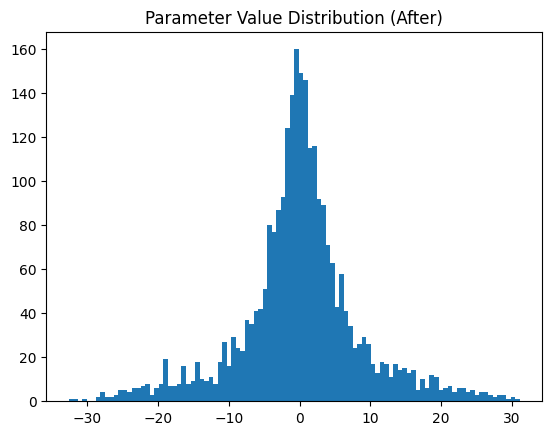

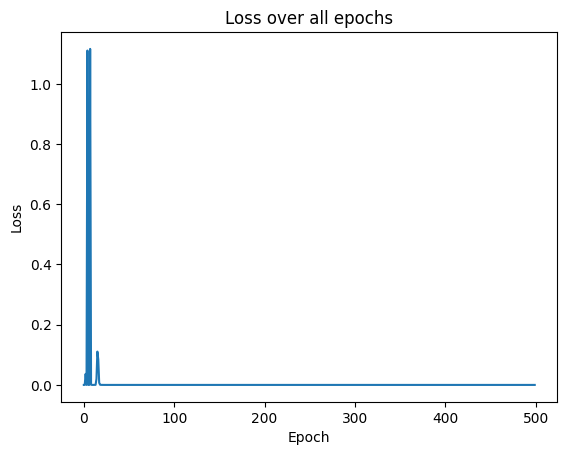

In [17]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Adadelta har tre hyperparametrar (weight decay är valbart)
lr = 1
rho = 0.9
epsilon = 1e-6
weight_decay = 0

optim_adadelta = torch.optim.Adadelta(model.parameters(), lr, rho, epsilon, weight_decay)

_loss = []
epochs = 1000
for _ in range(epochs):
    logits = model(embeddings_train)
    
    loss = F.cross_entropy(logits, train_labels)
    
    optim_adadelta.zero_grad()                          # sätt alla gradienter till noll innan vi räknas ut de nya gradienterna
    loss.backward()                                     # räknar ut partiell derivata av lossen med avseende på var och en av alla parametrar
    optim_adadelta.step()                               # i korthet uppdaterar vi alla parametrar som ω_n = ω_{n-1} - η del(L), där η är en funktion av hyperparametrar och tidigare gradienter (lr scheduler)

# Adam har fyra hyperparametrar (weight decay är valbart)
lr = 1
betas = (0.9, 0.999)    # skalkonstanter för gradienternas exponential running average och root mean square
epsilon = 1e-6
weight_decay = 0
optim_adam = torch.optim.Adam(model.parameters(), lr, betas, epsilon, weight_decay)

silver_epochs = 500
for _ in range(silver_epochs):
    logits = model(embeddings_silver)                   # ekvivalent med model.forward(...)
    
    loss = F.cross_entropy(logits, silver_labels)
    _loss.append(loss.item())

    optim_adam.zero_grad()                          # sätt alla gradienter till noll innan vi räknas ut de nya gradienterna
    loss.backward()                                     # räknar ut partiell derivata av lossen med avseende på var och en av alla parametrar
    optim_adam.step()  

params_after = torch.cat([p.detach().view(-1).cpu() for p in model.parameters()])

plt.hist(params_after.numpy(), bins=100)
plt.title("Parameter Value Distribution (After)")
plt.show()

plt.plot(_loss)
plt.title("Loss over all epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Vi testar och jämför resultatet mot Emelies Qwen 3 som fick 0.88.

In [28]:
import torch.nn.functional as F

# inferens
with torch.no_grad():
    logits = model.forward(embeddings_test)
    print(f"Logits shape: {logits.shape}")
    predictions = F.softmax(logits, dim=1)

print(f"Predictions shape: {predictions.shape}")
pred_labels = torch.argmax(predictions, dim=1)

# calculate accuracy, precision, recall and F1-score
true = 0
for predicted_label, true_label in zip(pred_labels, test_labels):
    if predicted_label == true_label:
        true += 1

accuracy = true / len(test_labels)
print(f"Accuracy: {accuracy:.2f}")

num_classes = 3

precision = []
recall = []

true_labels = test_labels

for cls in range(num_classes):
    tp = ((pred_labels == cls) & (true_labels == cls)).sum().item()
    fp = ((pred_labels == cls) & (true_labels != cls)).sum().item()
    fn = ((pred_labels != cls) & (true_labels == cls)).sum().item()

    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    precision.append(p)
    recall.append(r)
    
    print(f"Class {cls}: Precision: {p:.2f}, Recall: {r:.2f}")
            

# for sentence, prediction in zip(sentences, predictions):
#     prediction = prediction.tolist()
#     print(f"{sentence[:30]}:\t\t {[f"{x:.2f}" for x in prediction]}")

Logits shape: torch.Size([269, 3])
Predictions shape: torch.Size([269, 3])
Accuracy: 0.32
Class 0: Precision: 0.32, Recall: 0.74
Class 1: Precision: 0.48, Recall: 0.10
Class 2: Precision: 0.24, Recall: 0.22
